In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('social_media_engagement_5000.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types & Info:\n")
df.info()

df['post_date'] = pd.to_datetime(df['post_date'])

df.head()

Dataset Shape: (5020, 18)

Columns:
 ['post_id', 'post_date', 'post_type', 'category', 'country', 'age', 'gender', 'verified', 'device_type', 'time_of_day', 'sentiment', 'likes', 'comments', 'shares', 'impressions', 'watch_time', 'followers', 'hashtags']

Data Types & Info:

<class 'pandas.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      5020 non-null   str    
 1   post_date    5020 non-null   str    
 2   post_type    5020 non-null   str    
 3   category     5020 non-null   str    
 4   country      5020 non-null   str    
 5   age          5020 non-null   int64  
 6   gender       4990 non-null   str    
 7   verified     5020 non-null   str    
 8   device_type  5020 non-null   str    
 9   time_of_day  5020 non-null   str    
 10  sentiment    5020 non-null   str    
 11  likes        4970 non-null   float64
 12  comments     5020 non-null   int64 

,post_id,post_date,post_type,category,country,age,gender,verified,device_type,time_of_day,sentiment,likes,comments,shares,impressions,watch_time,followers,hashtags
0,POST_1,2025-01-01 00:00:00,Video,Fashion,India,36,Female,No,Desktop,Evening,Neutral,117.0,884,368,45776,176.40,697468,#lifestyle #daily #vlog
1,POST_2,2025-01-01 01:00:00,Carousel,Fashion,USA,38,Other,No,Mobile,Afternoon,neg,1614.0,192,481,23023,165.31,184801,#fashion #style #ootd
2,POST_3,2025-01-01 02:00:00,Reel,Fitness,India,58,Male,No,Mobile,Evening,Positive,1918.0,282,165,10212,105.63,899348,#tech #innovation #future
3,POST_4,2025-01-01 03:00:00,Video,Fashion,Canada,38,Other,No,Mobile,Afternoon,Positive,2240.0,253,156,12774,33.42,320620,#fashion #style #ootd
4,POST_5,2025-01-01 04:00:00,Image,Entertainment,USA,42,Female,No,Mobile,Night,pos,7931.0,503,180,6777,101.14,396522,#entertainment #fun #viral


In [2]:
df['likes'] = df['likes'].fillna(df['likes'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

df = df.drop_duplicates()

df['gender'] = df['gender'].str.strip().str.title()
df['sentiment'] = df['sentiment'].replace({'pos': 'Positive', 'neg': 'Negative'})

df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df['engagement_rate'] = np.round((df['engagement_score'] / df['impressions']) * 100, 2)

print("Data Cleaning and Feature Engineering completed!")
df.head()

Data Cleaning and Feature Engineering completed!


,post_id,post_date,post_type,category,country,age,gender,verified,device_type,time_of_day,...,likes,comments,shares,impressions,watch_time,followers,hashtags,hashtag_count,engagement_score,engagement_rate
0,POST_1,2025-01-01 00:00:00,Video,Fashion,India,36,Female,No,Desktop,Evening,...,117.0,884,368,45776,176.40,697468,#lifestyle #daily #vlog,3,1369.0,2.99
1,POST_2,2025-01-01 01:00:00,Carousel,Fashion,USA,38,Other,No,Mobile,Afternoon,...,1614.0,192,481,23023,165.31,184801,#fashion #style #ootd,3,2287.0,9.93
2,POST_3,2025-01-01 02:00:00,Reel,Fitness,India,58,Male,No,Mobile,Evening,...,1918.0,282,165,10212,105.63,899348,#tech #innovation #future,3,2365.0,23.16
3,POST_4,2025-01-01 03:00:00,Video,Fashion,Canada,38,Other,No,Mobile,Afternoon,...,2240.0,253,156,12774,33.42,320620,#fashion #style #ootd,3,2649.0,20.74
4,POST_5,2025-01-01 04:00:00,Image,Entertainment,USA,42,Female,No,Mobile,Night,...,7931.0,503,180,6777,101.14,396522,#entertainment #fun #viral,3,8614.0,127.11


In [3]:
print("--- Summary Statistics ---")
display(df.describe())

print("\n--- Average Likes by Post Type ---")
display(df.groupby('post_type')['likes'].mean().reset_index())

print("\n--- Average Engagement Rate by Country ---")
display(df.groupby('country')['engagement_rate'].mean().reset_index())

--- Summary Statistics ---


,post_date,age,likes,comments,shares,impressions,watch_time,followers,hashtag_count,engagement_score,engagement_rate
count,5000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000,5000.000000
mean,2025-04-15 03:30:00,40.943200,4997.208200,491.36900,252.031800,25007.211000,91.930428,491334.399000,3.0,5740.609000,70.781896
min,2025-01-01 00:00:00,18.000000,12.000000,0.00000,0.000000,101.000000,2.070000,1069.000000,3.0,122.000000,0.310000
25%,2025-02-22 01:45:00,29.000000,2484.500000,239.00000,129.000000,12509.000000,48.107500,237336.750000,3.0,3211.500000,12.807500
50%,2025-04-15 03:30:00,41.000000,5025.500000,488.00000,253.000000,25010.500000,93.080000,497643.500000,3.0,5793.000000,22.855000
75%,2025-06-06 05:15:00,53.000000,7498.250000,741.00000,377.000000,37440.500000,135.962500,737577.000000,3.0,8218.500000,46.162500
max,2025-07-28 07:00:00,64.000000,9999.000000,999.00000,499.000000,49971.000000,179.970000,999819.000000,3.0,11375.000000,9906.930000
std,NaN,13.604859,2879.812708,289.80586,143.966513,14460.208104,51.216796,289475.136557,0.0,2903.878978,274.180628



--- Average Likes by Post Type ---


,post_type,likes
0,Carousel,5152.182192
1,Image,5003.448400
2,Reel,5058.651849
3,Video,4860.437330



--- Average Engagement Rate by Country ---


,country,engagement_rate
0,Australia,64.803375
1,Canada,62.202767
2,India,70.722882
3,UK,67.161701
4,USA,78.987122


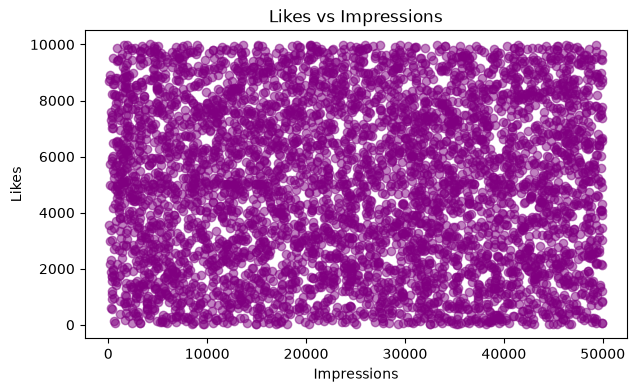

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(7, 4))
plt.scatter(df['impressions'], df['likes'], alpha=0.5, color='purple')
plt.title('Likes vs Impressions')
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.show()

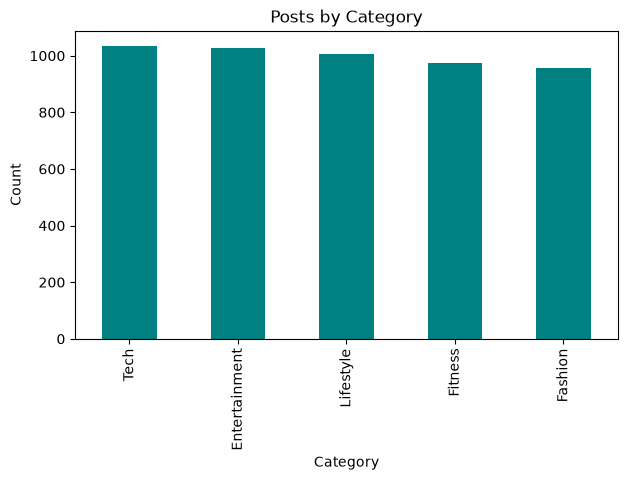

In [5]:
plt.figure(figsize=(7, 4))
df['category'].value_counts().plot(kind='bar', color='teal')
plt.title('Posts by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

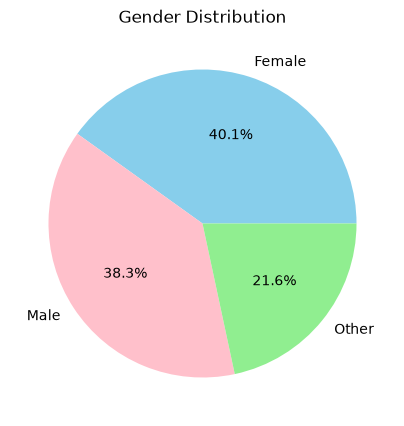

In [6]:
plt.figure(figsize=(5, 5))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'pink', 'lightgreen'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_2352\897504399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='post_type', palette='Set2')


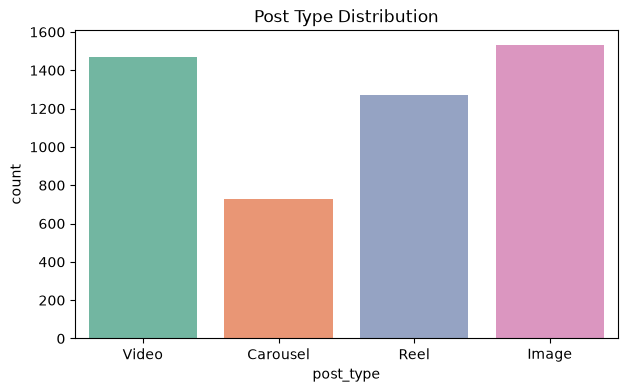

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='post_type', palette='Set2')
plt.title('Post Type Distribution')
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

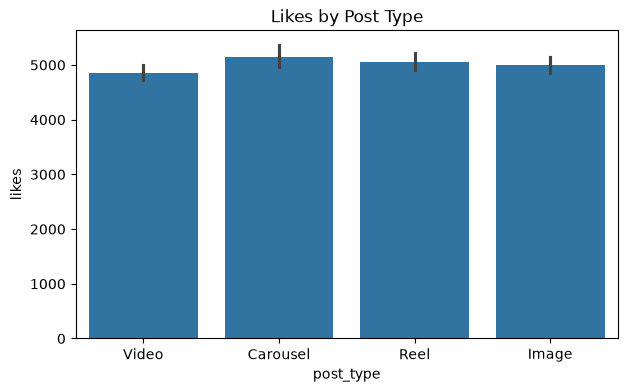

In [9]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='post_type', y='likes')
plt.title('Likes by Post Type')
plt.show()

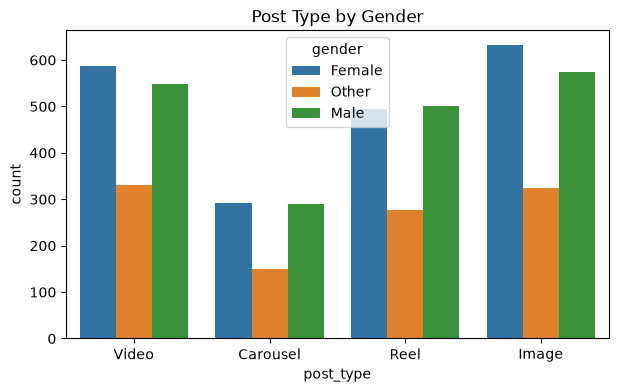

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='post_type', hue='gender')
plt.title('Post Type by Gender')
plt.show()

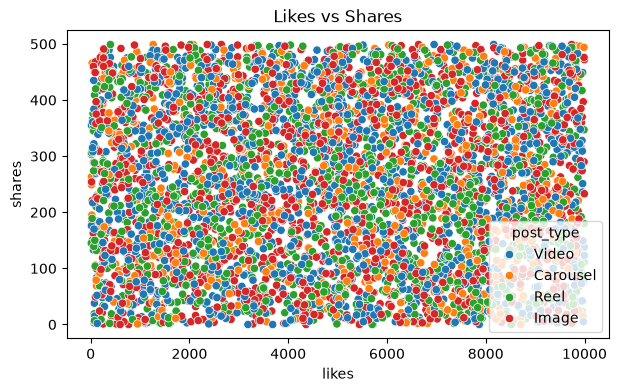

In [11]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='likes', y='shares', hue='post_type')
plt.title('Likes vs Shares')
plt.show()

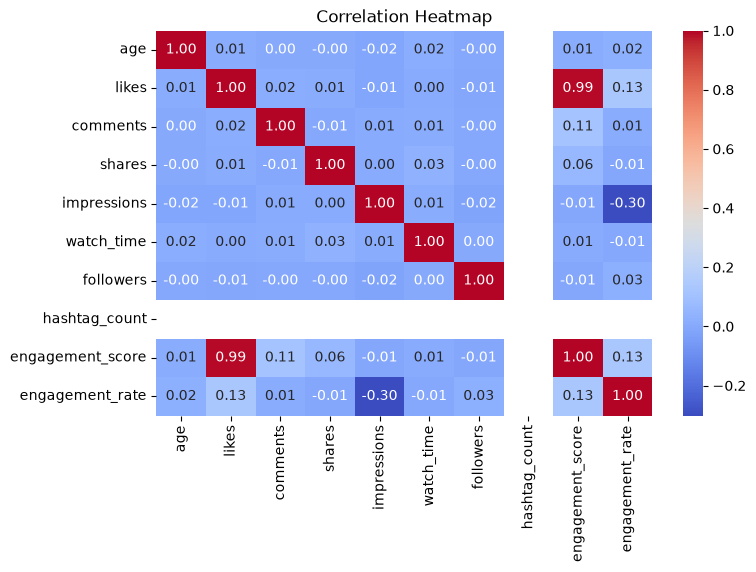

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

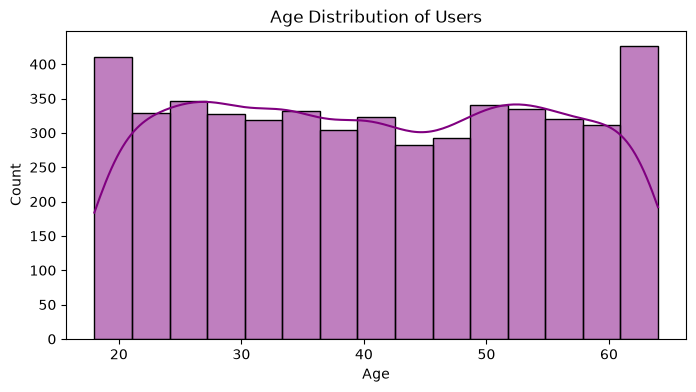

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=15, kde=True, color='purple')
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_2352\2475167137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='post_type', y='watch_time', palette='Set3')


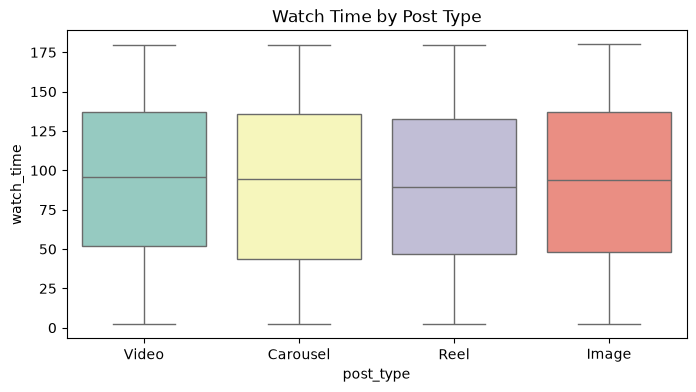

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='post_type', y='watch_time', palette='Set3')
plt.title('Watch Time by Post Type')
plt.show()

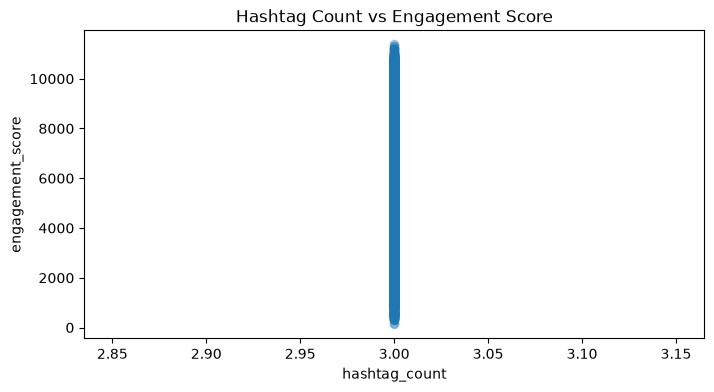

In [15]:
plt.figure(figsize=(8, 4))
sns.regplot(data=df, x='hashtag_count', y='engagement_score', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Hashtag Count vs Engagement Score')
plt.show()

In [16]:
top_5_posts = df.nlargest(5, 'engagement_score')
print(top_5_posts[['post_type', 'likes', 'shares', 'engagement_score']])

     post_type   likes  shares  engagement_score
4509  Carousel  9990.0     494           11375.0
1326     Image  9998.0     472           11304.0
3120     Image  9990.0     476           11296.0
1474     Video  9792.0     470           11252.0
332      Image  9816.0     420           11216.0


C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_2352\658654731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='post_type', y='engagement_rate', palette='Pastel1')


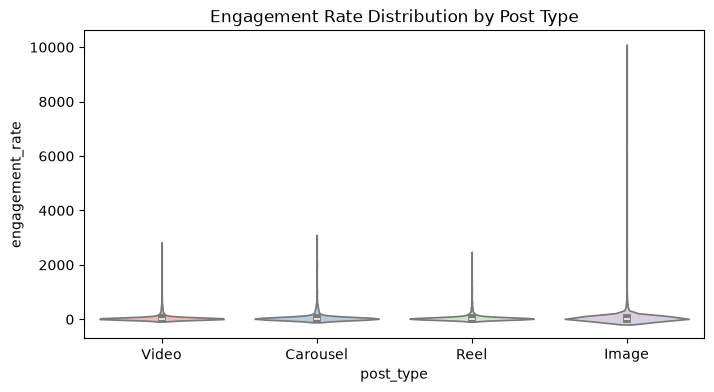

In [17]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='post_type', y='engagement_rate', palette='Pastel1')
plt.title('Engagement Rate Distribution by Post Type')
plt.show()

C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_2352\333683838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='post_type', y='engagement_rate', estimator='mean', errorbar=None, palette='mako')


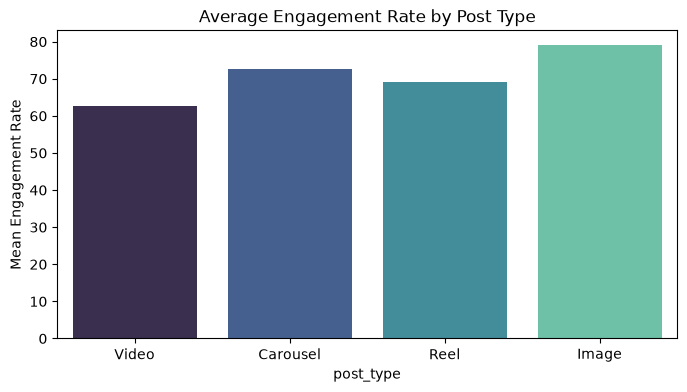

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='post_type', y='engagement_rate', estimator='mean', errorbar=None, palette='mako')
plt.title('Average Engagement Rate by Post Type')
plt.ylabel('Mean Engagement Rate')
plt.show()